# Benchmark 01 — MLP poco profundo (regresión, California Housing)

**Universidad Central de Venezuela**

Facultad de Ciencias | Escuela de Computación



**Estudiante:** Rafael Eduardo Contreras

**Cédula / ID:** 30391915

**Tutor:** Eugenio Scalise

---

## Introducción

Este notebook compara el rendimiento de inferencia cifrada del SDK desarrollado
con otras bibliotecas similares. Las bibliotecas evaluadas en este notebook son:

- **Nuestra SDK**: CKKS sobre GPU, basada en HEonGPU
- **Concrete-ML**: TFHE sobre GPU, compilador de Zama

> **TenSEAL** queda fuera de este benchmark: la ReLU aproximada de Cheon
> tiene profundidad multiplicativa ~101 y TenSEAL no soporta
> bootstrapping, por lo que no puede ejecutar la red.

Para cada biblioteca se mide:

- **Latencia por muestra**: segundos de inferencia cifrada extremo a extremo.
- **Coeficiente de determinación R²**: comparando contra la inferencia en claro como referencia.
- **Pico de VRAM y RAM**: memoria de GPU y de proceso durante la inferencia.

Como punto de comparación adicional se incluye la inferencia con PyTorch, que sirve como cota
inferior de tiempo y cota superior de exactitud para todas las versiones
cifradas.

## Instalación de dependencias

La siguiente celda detecta los paquetes que faltan en el entorno y sólo
instala lo necesario.

> **Nota CUDA:** `fhe-sdk` compila CUDA al instalarse y necesita CUDA Toolkit 12.8 + GPU
>
> Para Concrete-ML, `concrete-python` se reinstala desde el índice GPU de
> Zama (`pypi.zama.ai/gpu`) — el wheel de PyPI es sólo CPU.

In [1]:
!pip install -q numpy pandas matplotlib scikit-learn psutil pynvml


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [1]:
!BUILD_JOBS=$(nproc) pip install fhe-sdk==0.1.3

  Using cached fhe_sdk-0.1.3.tar.gz (1.7 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fhe-sdk: filename=fhe_sdk-0.1.3-cp311-cp311-linux_x86_64.whl size=23358706 sha256=8162994fbe1353def1eab68e5d866c6d265accbea2856ac5fcdbfa16e5b3bf15
  Stored in directory: /root/.cache/pip/wheels/c4/4c/7a/378efb3d4c9cd6285512a6eebf741251d9a923c2468fcf58d5
Successfully built fhe-sdk
  Attempting uninstall: fhe-sdk
    Found existing installation: fhe-sdk 0.1.2
    Uninstalling fhe-sdk-0.1.2:
      Successfully uninstalled fhe-sdk-0.1.2

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
!pip uninstall -y concrete-python
!pip install concrete-ml
!pip install --no-deps --extra-index-url https://pypi.zama.ai/gpu --trusted-host pypi.zama.ai 'concrete-python==2024.12.19'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.6/626.6 kB 122.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 MB 110.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 MB 114.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 144.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 78.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 678.1/678.1 kB 138.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 160.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 286.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 185.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.2/779.2 MB 78.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 125.6 MB/s eta 0:00:0000:0100

In [1]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())     # True

import concrete.compiler
print(concrete.compiler.check_gpu_enabled())     # True
print(concrete.compiler.check_gpu_available())   # True

/usr/local/lib/python3.11/dist-packages/torch/cuda/__init__.py:56: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


2.3.1+cu121
12.1
True
True
True


In [2]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("CUDA no disponible: este benchmark requiere GPU (SDK y Concrete-ML).")
DEVICE = torch.device("cuda")
print(f"PyTorch device = {DEVICE}")

PyTorch device = cuda


In [3]:
import time
import gc
import psutil
import pynvml

pynvml.nvmlInit()
_NVML = pynvml.nvmlDeviceGetHandleByIndex(0)


def free_gpu():
    """Best-effort: libera lo que torch tenga cacheado. No alcanza a las
    asignaciones de HEonGPU (C++ puro), pero ayuda con tensors de PyTorch
    y con el cache interno de Concrete-ML."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()


class Measure:
    def __init__(self):
        self._proc = psutil.Process()

    def __enter__(self):
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        self._t0 = time.perf_counter()
        return self

    def __exit__(self, *_):
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        self.elapsed_s   = time.perf_counter() - self._t0
        self.peak_rss_mb  = self._proc.memory_info().rss / 1024**2
        self.peak_vram_mb = pynvml.nvmlDeviceGetMemoryInfo(_NVML).used / 1024**2
        self.abs_peak_vram_mb = self.peak_vram_mb
        return False

## Red y entrenamiento

### Datos: California Housing

Dataset clásico de regresión incluido en `scikit-learn`: 20 640 distritos
del censo de California, 8 atributos numéricos por distrito (ingreso
medio, ocupación media, etc.) y el valor mediano de la vivienda como
objetivo. Se estandarizan tanto los atributos como el objetivo con
estadísticas del split de entrenamiento; `denormalize_target` recupera
la escala original en dólares de $100 000.

In [4]:
import numpy as np
from dataclasses import dataclass
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 30391915

@dataclass
class Dataset:
    x_train: np.ndarray
    x_test: np.ndarray
    y_train: np.ndarray
    y_test: np.ndarray
    y_mean: float
    y_std: float

    @property
    def n_features(self) -> int:
        return self.x_train.shape[1]

    def denormalize_target(self, y):
        return np.asarray(y, dtype=float) * self.y_std + self.y_mean


def load_california_housing(test_size: float = 0.2) -> Dataset:
    raw = fetch_california_housing()
    x_tr, x_te, y_tr, y_te = train_test_split(
        raw.data, raw.target, test_size=test_size, random_state=SEED,
    )
    scaler = StandardScaler().fit(x_tr)
    x_tr, x_te = scaler.transform(x_tr), scaler.transform(x_te)
    y_mean, y_std = float(y_tr.mean()), float(y_tr.std())
    y_tr = (y_tr - y_mean) / y_std
    y_te = (y_te - y_mean) / y_std
    return Dataset(x_tr, x_te, y_tr, y_te, y_mean, y_std)

data = load_california_housing()
print(f"train: {data.x_train.shape}, test: {data.x_test.shape}")

train: (16512, 8), test: (4128, 8)


### Arquitectura y entrenamiento

`Linear(8 → 128) → ReLU → Linear(128 → 64) → ReLU → Linear(64 → 1)`

In [5]:
from torch import nn

def build_network(n_features):
    return nn.Sequential(
        nn.Linear(n_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 1),
    )

In [6]:
from torch import nn

def train_regression(model, data, epochs=400, batch_size=256, lr=1e-3):
    x = torch.tensor(data.x_train, dtype=torch.float32, device=DEVICE)
    y = torch.tensor(data.y_train, dtype=torch.float32, device=DEVICE).reshape(-1, 1)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    n = len(x)
    model.train()
    for _ in range(epochs):
        perm = torch.randperm(n, device=DEVICE)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss_fn(model(x[idx]), y[idx]).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
    model.eval()
    return model


torch_model = build_network(data.n_features).to(DEVICE)
train_regression(torch_model, data)
print(torch_model)

Sequential(
  (0): Linear(in_features=8, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=1, bias=True)
)


## Inferencia cifrada

### Nuestra SDK

Implementación del esquema RNS-CKKS construida sobre HEonGPU, con
todas las operaciones (multiplicación, rotación, rescale, bootstrapping)
ejecutadas en la GPU vía CUDA.

In [7]:
from api import FHEContext
from api.layers.linear import Linear
from api.functions.relu import ReLU
from api.sequential import Sequential
from core.enums import SecurityLevel

# 128 bits de seguridad
# para esta profundidad el chain de bootstrapping requiere n = 65536, lo que
# implica un set de claves Galois de ~24 GB en VRAM

POLY_DEGREE   = 65_536
COEFF_MODULUS = [60] + [52] * 28 + [60]
SCALE         = 2**52
SECURITY      = SecurityLevel.SEC128

# configuracion rapida e insegura, solo para development
# POLY_DEGREE   = 8_192
# COEFF_MODULUS = [60] + [50] * 28 + [60]
# SCALE         = 2**50
# SECURITY      = SecurityLevel.NONE

RELU_DEGREES  = (5,) * 12

In [8]:
def to_sdk_model(torch_model):
    cpu_model = torch_model.cpu()
    layers = []
    for m in cpu_model:
        if isinstance(m, torch.nn.Linear):
            layers.append(Linear(
                m.in_features, m.out_features,
                m.weight.detach().numpy(), m.bias.detach().numpy(),
            ))
        else:
            layers.append(ReLU(degrees=RELU_DEGREES))
    return Sequential(layers)

### Concrete-ML

Compilador FHE de Zama basado en TFHE. A diferencia de CKKS, TFHE
hace **bootstrapping programable** por operación, lo que le permite
ejecutar ReLU real (no aproximada) y redes de profundidad arbitraria.
Toda la aritmética es entera, así que el modelo PyTorch se cuantiza antes de
compilarse al circuito TFHE.

In [9]:
from concrete.ml.torch.compile import compile_torch_model

# N_BITS=parametro de cuantizacion.
# N_CALIB=muestras del set de entrenamiento usadas para fijar la cuantización

N_BITS     = 6
N_CALIB    = 200

if not torch.cuda.is_available():
    raise RuntimeError("CUDA no disponible: Concrete-ML requiere GPU en este benchmark.")

import concrete.compiler
if not concrete.compiler.check_gpu_enabled():
    raise RuntimeError(
        "Build de concrete-python sin soporte GPU. "
        "Reinstala desde https://pypi.zama.ai/gpu y reinicia el kernel."
    )
if not concrete.compiler.check_gpu_available():
    raise RuntimeError("Concrete-ML no detecta la GPU (check_gpu_available()=False).")

CML_DEVICE = "cuda"
print(f"Concrete-ML device = {CML_DEVICE}")

calib = torch.tensor(data.x_train[:N_CALIB], dtype=torch.float32)

Concrete-ML device = cuda


## Resultados

Cada biblioteca corre el mismo subconjunto de prueba con los mismos pesos
plaintext. Las métricas reportadas son:

- **Latencia media por muestra** — incluye cifrado, inferencia y descifrado.
- **R²** — calidad de la predicción cifrada. La columna
  *baseline* corresponde a la inferencia en plano.
- **Δ VRAM (MB)** — memoria GPU adicional consumida durante el bloque medido,
  respecto al estado al iniciar. Se reporta delta (no absoluto) porque pynvml
  ve la VRAM acumulada del dispositivo; un absoluto incluiría las
  asignaciones que los backends previos dejaron residentes (claves Galois
  de la SDK, etc.).
- **Δ RAM (MB)** — análogo para el proceso Python (RSS).

> Para Concrete-ML, la latencia y la memoria se miden con cifrado real
> (`fhe="execute"`, 1 muestra) y la precisión se calcula con simulación
> (`fhe="simulate"`, N muestras). Ambos modos ejecutan el **mismo circuito
> cuantizado** — la simulación produce salidas numéricamente equivalentes
> sin pagar el coste FHE, lo que permite estimar precisión sobre muestras
> suficientes en segundos en lugar de horas.

In [10]:
N_TEST = 10
x_test = data.x_test[:N_TEST]
y_test = data.y_test[:N_TEST]

torch_model.to(DEVICE).eval()
with torch.no_grad(), Measure() as m_plain:
    x_gpu = torch.tensor(x_test, dtype=torch.float32, device=DEVICE)
    plain_t = torch_model(x_gpu)
    plain = plain_t.cpu().numpy().reshape(-1)
plain_latency = m_plain.elapsed_s / N_TEST

In [15]:
import gc
for _n in ("sdk_model", "ctx"):
    if _n in globals():
        del globals()[_n]
gc.collect()
free_gpu()

sdk_pred = np.empty(N_TEST)
with Measure() as m_sdk:
    ctx = (FHEContext()
        .set_poly_modulus_degree(POLY_DEGREE)
        .set_coeff_modulus_bit_sizes(COEFF_MODULUS)
        .set_scale(SCALE)
        .set_security_level(SECURITY)
        .build())
    sdk_model = to_sdk_model(torch_model)
    sdk_model.compile(ctx, calibration_data=data.x_train)
    print(f"profundidad multiplicativa: "
          f"{sum(l.mult_depth() for l in sdk_model._layers)}")
    print(f"bootstrapping: {ctx._bootstrapping_ready}")

    for i, x in enumerate(x_test):
        print(f"[SDK {i+1}/{N_TEST}]", flush=True)
        sdk_pred[i] = sdk_model(sdk_model.input(ctx, x.tolist())).decrypt()[0]
sdk_latency = m_sdk.elapsed_s / N_TEST

profundidad multiplicativa: 101
bootstrapping: True
[SDK 1/10]
[SDK 2/10]
[SDK 3/10]
[SDK 4/10]
[SDK 5/10]
[SDK 6/10]
[SDK 7/10]
[SDK 8/10]
[SDK 9/10]
[SDK 10/10]


In [12]:
# para concrete-ml dividimos la medicion
#  1) fhe="execute": cifrado real, mide latencia + memoria (incluyendo compile)
#  2) fhe="simulate": circuito cuantizado evaluado, sirve para medir R²
#     sobre muchas muestras sin esperar horas.
#
# Suelto primero el modelo SDK para que el snapshot de Concrete-ML no incluya
# las claves Galois residentes del backend anterior.

import gc
for _n in ("sdk_model", "ctx"):
    if _n in globals():
        del globals()[_n]
gc.collect()
free_gpu()

N_EXECUTE  = 1
N_SIMULATE = 20

x_exec = x_test[:N_EXECUTE].astype(np.float32)
with Measure() as m_cml:
    # Una celda anterior (inferencia plaintext) movio `torch_model` a CUDA.
    # `torch_model.cpu()` es in-place y devuelve el mismo objeto, asi que
    # `torch_cpu` antes tambien quedaria en CUDA. Forzamos CPU aqui para que
    # compile_torch_model reciba el modelo en el mismo device que `calib`.
    torch_cpu = torch_model.cpu()
    cml_model = compile_torch_model(
        torch_cpu, torch_inputset=calib, n_bits=N_BITS, device=CML_DEVICE,
    )
    for i, x in enumerate(x_exec):
        print(f"[concrete-ml execute {i+1}/{N_EXECUTE}]", flush=True)
        _ = cml_model.forward(x.reshape(1, -1), fhe="execute")
cml_latency = m_cml.elapsed_s / N_EXECUTE

print(f"[concrete-ml simulate x{N_SIMULATE}]", flush=True)
x_sim = data.x_test[:N_SIMULATE].astype(np.float32)
y_test_sim = data.y_test[:N_SIMULATE]
cml_pred = np.empty(N_SIMULATE)
for i, x in enumerate(x_sim):
    cml_pred[i] = float(np.asarray(
        cml_model.forward(x.reshape(1, -1), fhe="simulate")
    ).reshape(-1)[0])

[concrete-ml execute 1/1]
[concrete-ml simulate x20]


In [16]:
import pandas as pd

def r2(y_true_z, y_pred_z):
    y_true = data.denormalize_target(y_true_z)
    y_pred = data.denormalize_target(y_pred_z)
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum() + 1e-12
    return 1 - ss_res / ss_tot

results = pd.DataFrame([
    {"backend": f"plaintext (PyTorch {DEVICE.type.upper()})",
     "latency_s": plain_latency, "R²": r2(y_test, plain),
     "VRAM_MB": m_plain.peak_vram_mb, "RAM_MB": m_plain.peak_rss_mb,
     "muestras": int(N_TEST), "seguridad": "no aplica"},
    {"backend": "SDK propia (CKKS, GPU)", "latency_s": sdk_latency,
     "R²": r2(y_test, sdk_pred),
     "VRAM_MB": m_sdk.peak_vram_mb, "RAM_MB": m_sdk.peak_rss_mb,
     "muestras": int(N_TEST), "seguridad": str(SECURITY).split('.')[-1]},
    {"backend": f"Concrete-ML (TFHE, {CML_DEVICE.upper()})",
     "latency_s": cml_latency, "R²": r2(y_test_sim, cml_pred),
     "VRAM_MB": m_cml.peak_vram_mb, "RAM_MB": m_cml.peak_rss_mb,
     "muestras": f"{N_EXECUTE} (lat) / {N_SIMULATE} (R²)", "seguridad": "SEC128"},
])
results

,backend,latency_s,R²,VRAM_MB,RAM_MB,muestras,seguridad
0,plaintext (PyTorch CUDA),0.000400,0.890407,726.75,1119.972656,10,no aplica
1,"SDK propia (CKKS, GPU)",9.191406,0.889627,22276.75,3050.773438,10,SEC128
2,"Concrete-ML (TFHE, CUDA)",749.450794,0.148915,22276.75,2976.820312,1 (lat) / 20 (R²),SEC128


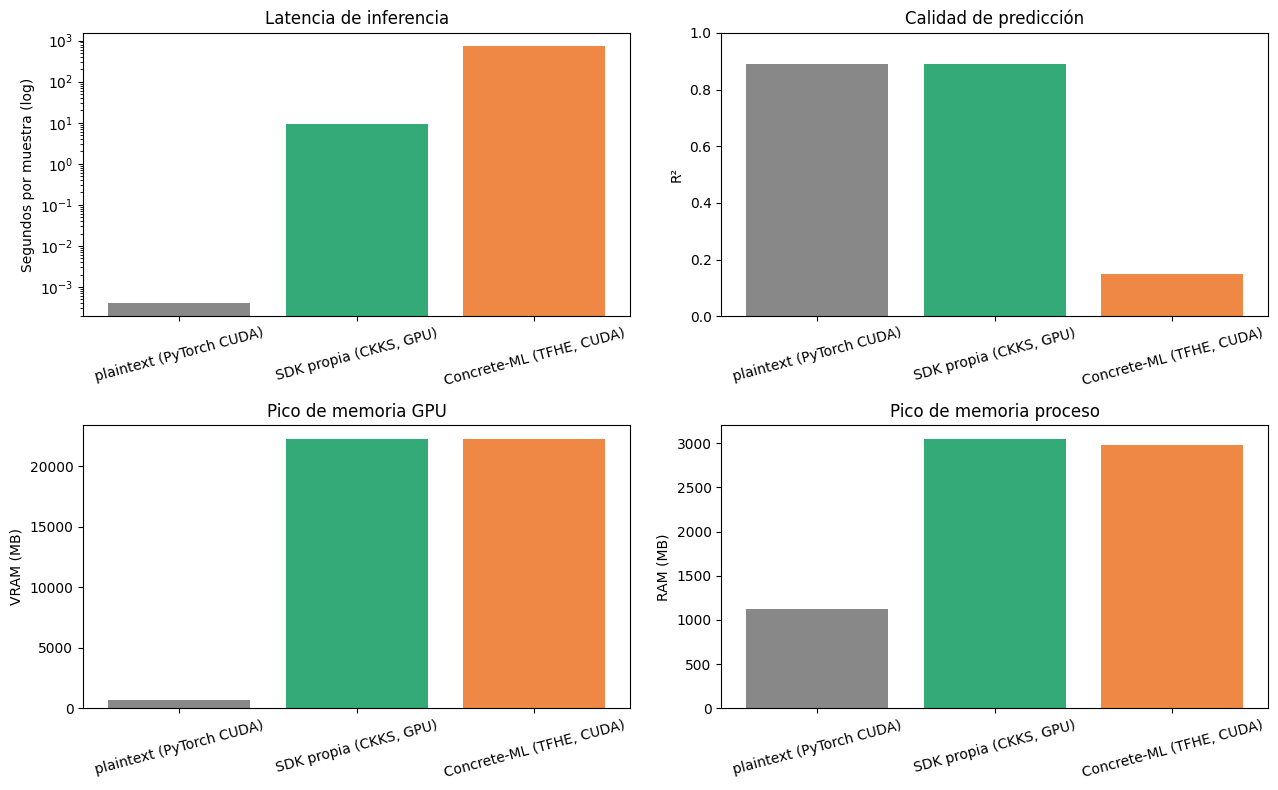

In [17]:
import matplotlib.pyplot as plt

palette = ["#888", "#3a7", "#e84", "#39c"]
colors = palette[: len(results)]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].bar(results["backend"], results["latency_s"], color=colors)
axes[0, 0].set_yscale("log")
axes[0, 0].set_ylabel("Segundos por muestra (log)")
axes[0, 0].set_title("Latencia de inferencia")
axes[0, 0].tick_params(axis="x", rotation=15)

axes[0, 1].bar(results["backend"], results["R²"], color=colors)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_ylabel("R²")
axes[0, 1].set_title("Calidad de predicción")
axes[0, 1].tick_params(axis="x", rotation=15)

axes[1, 0].bar(results["backend"], results["VRAM_MB"], color=colors)
axes[1, 0].set_ylabel("VRAM (MB)")
axes[1, 0].set_title("Pico de memoria GPU")
axes[1, 0].tick_params(axis="x", rotation=15)

axes[1, 1].bar(results["backend"], results["RAM_MB"], color=colors)
axes[1, 1].set_ylabel("RAM (MB)")
axes[1, 1].set_title("Pico de memoria proceso")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()